# **Sales Analysis**

In [21]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [22]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [23]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [24]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,net_revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
172513,2024-05-15 09:37:10.317908,2024,5,Wed,Morning,No,Nancy Johnson,Female,75,65+,Regular,Belgium,Completed,Health,Personal Care,124.49,Premium,3,Small Basket,373.47,18.67,5,Low Discount,Yes,354.80,High,140.78,39.68,Debit Card,Economy,18.65,5.26,12,Slow,Belgium,Domestic,4,45.30,Medium,No,17.00,Medium,18,Yes,54.80,Medium,Tablet,Google Ads,Referral
727670,2025-08-22 17:00:08.630208,2025,8,Fri,Afternoon,No,Joseph Johnson,Male,71,65+,Regular,United States,Pending,Home,Furniture,288.75,Luxury,5,Bulk,"1,443.75",216.56,15,Medium Discount,Yes,"1,227.19",Very High,561.19,45.73,Bank Transfer,Standard,12.00,0.98,12,Slow,United States,Domestic,3,62.80,Medium,No,27.40,Medium,10,No,64.70,Medium,Mobile,Affiliate,Direct
497993,2025-07-07 23:05:37.329042,2025,7,Mon,Evening,No,Chris Morgan,Male,24,18-24,Regular,United States,Cancelled,Home,Decor,182.10,Premium,1,Single,182.10,18.21,10,Low Discount,Yes,163.89,Medium,68.55,41.83,Bank Transfer,Express,3.03,1.85,13,Slow,United States,Domestic,2,61.20,Medium,Yes,53.60,High,10,No,98.70,High,Tablet,Facebook,Direct
108846,2025-11-29 04:56:26.586121,2025,11,Sat,Night,Yes,John Riley,Male,47,45-54,Regular,United Kingdom,Returned,Health,Medical Devices,57.89,Mid-Range,5,Bulk,289.45,28.95,10,Low Discount,Yes,260.50,Medium,109.10,41.88,Apple Pay,Express,1.18,0.45,7,Standard,United Kingdom,Domestic,2,23.80,Low,Yes,51.10,High,4,Yes,25.90,Low,Mobile,Google Ads,Email
599386,2025-03-08 22:26:14.373192,2025,3,Sat,Evening,Yes,Brian King PhD,Male,34,25-34,Premium,Australia,Completed,Health,Fitness,158.92,Premium,3,Small Basket,476.76,23.84,5,Low Discount,Yes,452.92,High,242.74,53.59,Credit Card,Next Day,3.18,0.70,9,Slow,Australia,Domestic,5,63.70,Medium,Yes,54.50,High,2,Yes,62.10,Medium,Mobile,Affiliate,Email
816083,2024-11-23 20:34:19.479644,2024,11,Sat,Evening,Yes,Robin Lee,Female,35,35-44,Regular,United Kingdom,Completed,Electronics,Laptops,483.53,Luxury,3,Small Basket,"1,450.59",0.00,0,No Discount,No,"1,450.59",Very High,493.26,34.00,Bank Transfer,Economy,5.89,0.41,1,Fast,United Kingdom,Domestic,4,8.60,Low,Yes,17.30,Medium,20,Yes,77.10,High,Mobile,Instagram,Search
1677,2025-01-04 14:42:36.729486,2025,1,Sat,Afternoon,Yes,James Miller,Male,57,55-64,Premium,Germany,Completed,Clothing,Mens Wear,21.90,Budget,2,Small Basket,43.80,2.19,5,Low Discount,Yes,41.61,Low,12.49,30.02,Apple Pay,Next Day,4.36,10.48,1,Fast,Germany,Domestic,5,56.40,Medium,No,36.40,Medium,10,Yes,31.20,Medium,Desktop,Instagram,Social
657202,2024-11-03 14:10:35.504400,2024,11,Sun,Afternoon,Yes,Ronald Nolan,Male,57,55-64,Premium,United Kingdom,Returned,Clothing,Accessories,44.77,Budget,2,Small Basket,89.54,17.91,20,Medium Discount,Yes,71.63,Low,16.83,23.50,Bank Transfer,Standard,22.31,31.15,9,Slow,United Kingdom,Domestic,4,56.80,Medium,Yes,52.10,High,14,No,5.20,Low,Tablet,Email,Referral
749094,2024-12-29 21:34:04.050263,2024,12,Sun,Evening,Yes,Thomas Mason,Male,51,45-54,Regular,United Kingdom,Returned,Clothing,Womens Wear,19.65,Budget,5,Bulk,98.25,9.82,10,Low Discount,Yes,88.43,Low,36.53,41.31,Bank Transfer,Standard,4.22,4.77,9,Slow,United Kingdom,Domestic,2,73.50,High,No,53.10,High,11,No,65.40,Medium,Mobile,Facebook,Referral
175324,2024-12-24 06:41:01.154541,2024,12,Tue,Morning,No,Sally Singh,Female,22,18-24,Regular,Belgium,Returned,Sports,Accessories,2

## 1. Revenue Performance

### 1.1 Revenue by Year

In [ ]:
yearly_revenue = (
    sales_df.groupby('order_year')['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='net_revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['net_revenue_usd']):
    ax.annotate(
        f'${y:,.2f}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Revenue by Month

In [ ]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

monthly_revenue = (
    sales_df.assign(
        order_month_name=sales_df['order_month'].map(month_map)
    )
    .groupby('order_month_name')['net_revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['net_revenue_usd']):
    ax.annotate(
        f'${y:,.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Revenue by Day of Week

In [ ]:
day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['net_revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['net_revenue_usd']):
    ax.annotate(
        f'${y:,.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Day of Week Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Revenue by Part of Day

In [ ]:

part_day_revenue = (
    sales_df.groupby('part_day')['net_revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='net_revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.5 Revenue: Weekdays vs Weekends

In [ ]:
is_weekend_revenue = (
    sales_df.groupby('is_weekend')['net_revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='net_revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Product Sales Performance

### 2.1 Revenue by Category

In [ ]:

category_revenue = (
    sales_df.groupby('category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='net_revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Top 10 Revenue Sub-Categories

In [ ]:
subcategory_revenue = (
    sales_df.groupby('sub_category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='net_revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )
    

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Average Unit Price by Category and Price Tier

In [ ]:
price_category = (
    sales_df
    .groupby(['category', 'price_tier'])['unit_price_usd']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=price_category,
    x='unit_price_usd',
    y='category',
    hue='price_tier',
    palette='tab10',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Categories with Highest Price and its Tier', fontsize=14, pad=15)
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Total Quantity Sold by Category

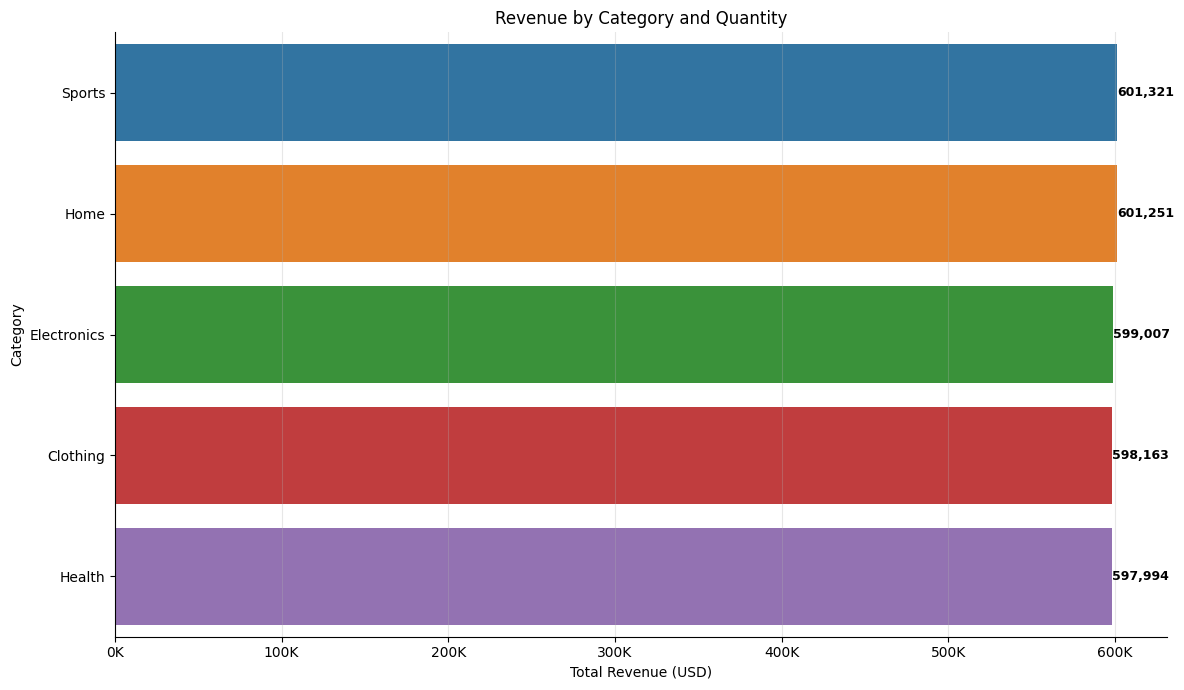

In [57]:
quantity_category = (
    sales_df
    .groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=quantity_category,
    x='quantity',
    y='category',
    palette='tab10',
    hue='category',
    legend=False,
    orient='h',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        label_type='edge',
        color='black',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category and Quantity')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Geographic Sales Performance

### 3.1 Revenue by Country

C:\Users\User\AppData\Local\Temp\ipykernel_2540\2291804543.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


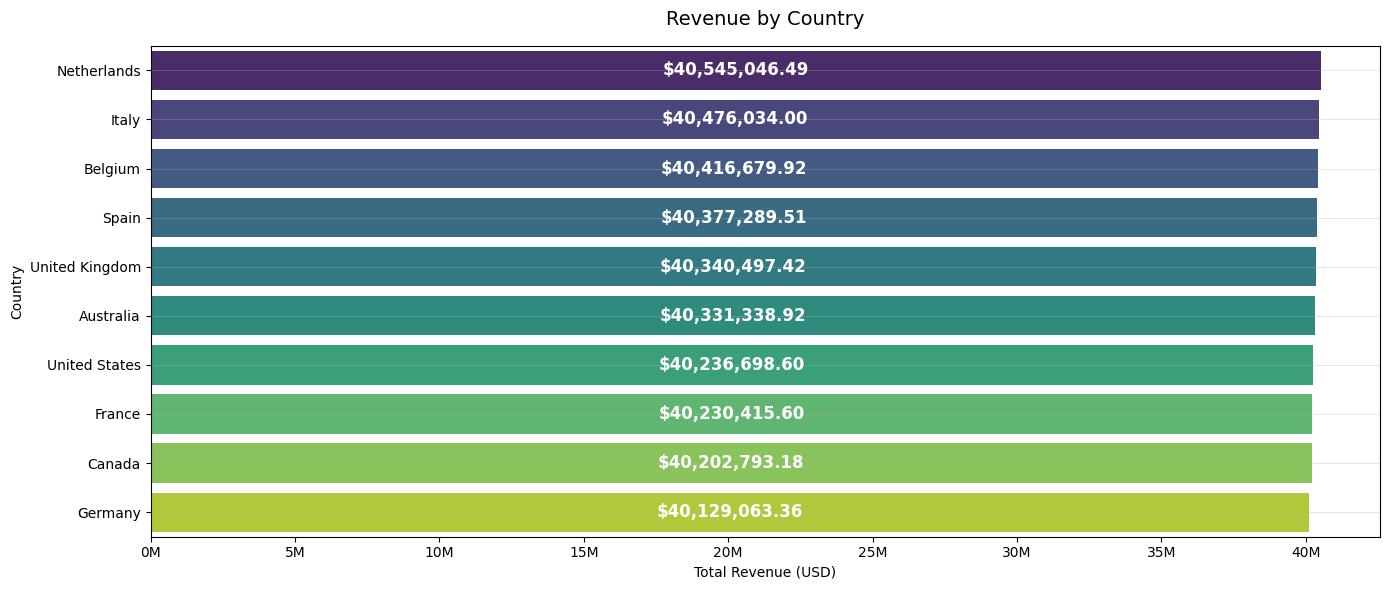

In [50]:
country_revenue = (
    sales_df.groupby('country')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_revenue,
    x='net_revenue_usd',
    y='country',
    orient='h',
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold',
    )

plt.title('Revenue by Country', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Revenue by Country Across Years

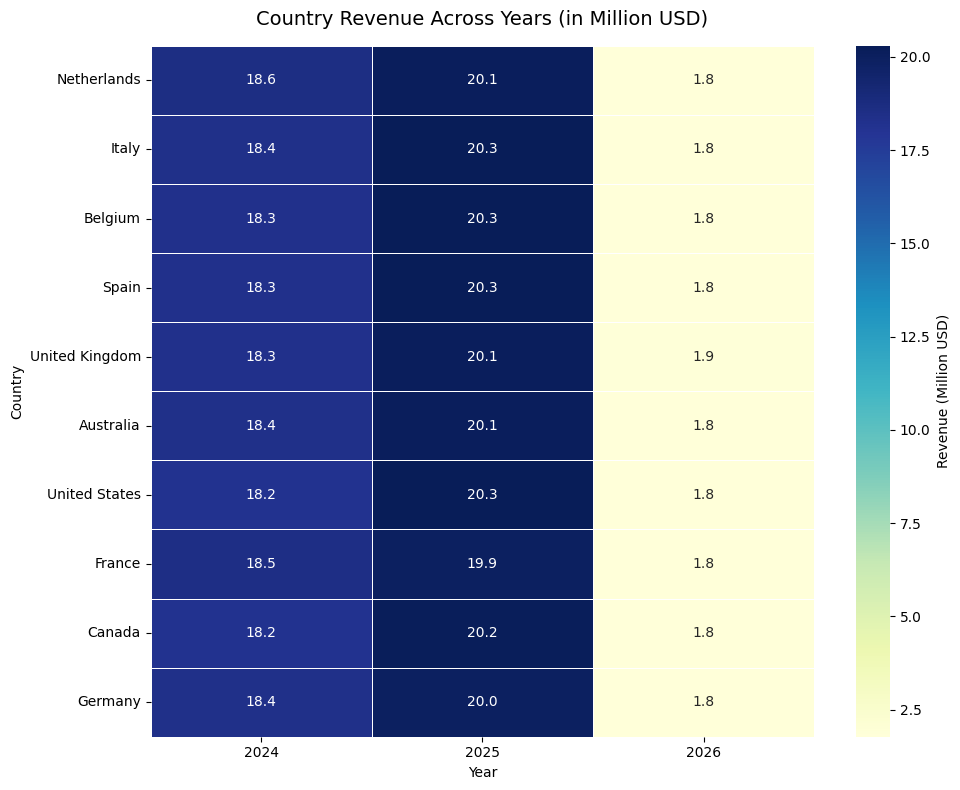

In [ ]:
# Prepare data
country_yearly = (
    sales_df.groupby(['country', 'order_year'])['net_revenue_usd']
    .sum()
    .unstack(fill_value=0)          # years become columns
)

# Optional: sort by total revenue
country_yearly = country_yearly.loc[
    country_yearly.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    country_yearly / 1e6,           # show in millions
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Revenue (Million USD)'}
)

plt.title('Country Revenue Across Years (in Million USD)', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## 4. Order Value Analysis

### 4.1 Revenue by Order Value Segment

### 4.2 Order Value Segment Across Categories

## 5. Customer Sales Analysis

### 5.1 Top 15 Customers by Revenue

### 5.2 Revenue Contribution by Customer Segment

### 5.3 Revenue Contribution by Age Group

## 6. Profitability Analysis

### 6.1 Profit by Category

### 6.2 Profit Margin by Category

### 6.3 Profit by Country

### 6.4 Revenue vs Profit by Category

## 7. Discount Analysis

### 7.1 Gross vs Net Revenue

### 7.2 Discount Impact by Year

### 7.3 Discounted vs Non-Discounted Transactions

### 7.4 Discounted vs Non-Discounted Profitability

## 1.4 Revenue by Order Value Segment

C:\Users\User\AppData\Local\Temp\ipykernel_2540\2939955942.py:16: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(


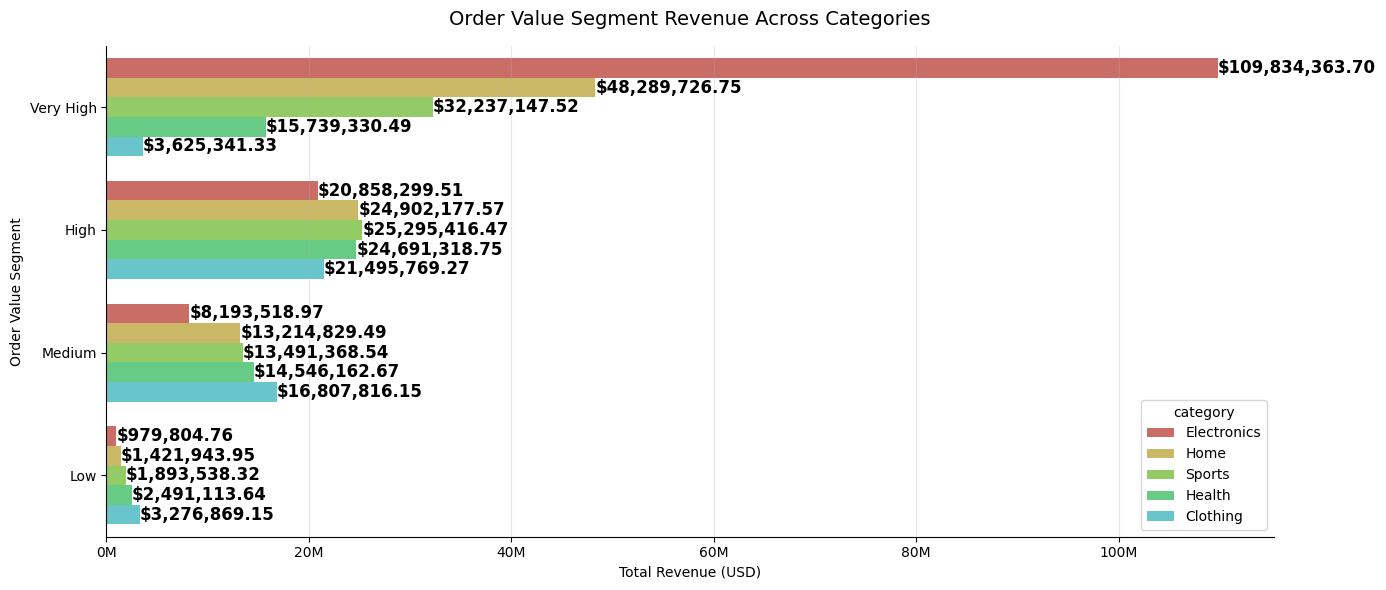

In [35]:
# 1.4.1 Order Value Segment Revenue Across Categories

order_value_segment_revenue = sales_df.groupby(
    ['order_value_segment', 'category']
)['net_revenue_usd'].sum().reset_index().sort_values('net_revenue_usd')


order_value_segment_revenue['order_value_segment'] = pd.Categorical(
    order_value_segment_revenue['order_value_segment'],
    categories=['Very High', 'High', 'Medium', 'Low'],
    ordered=True
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='net_revenue_usd',
    y='order_value_segment',
    hue='category',
    palette=sns.color_palette('hls',8),
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Order Value Segment Revenue Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 Customers

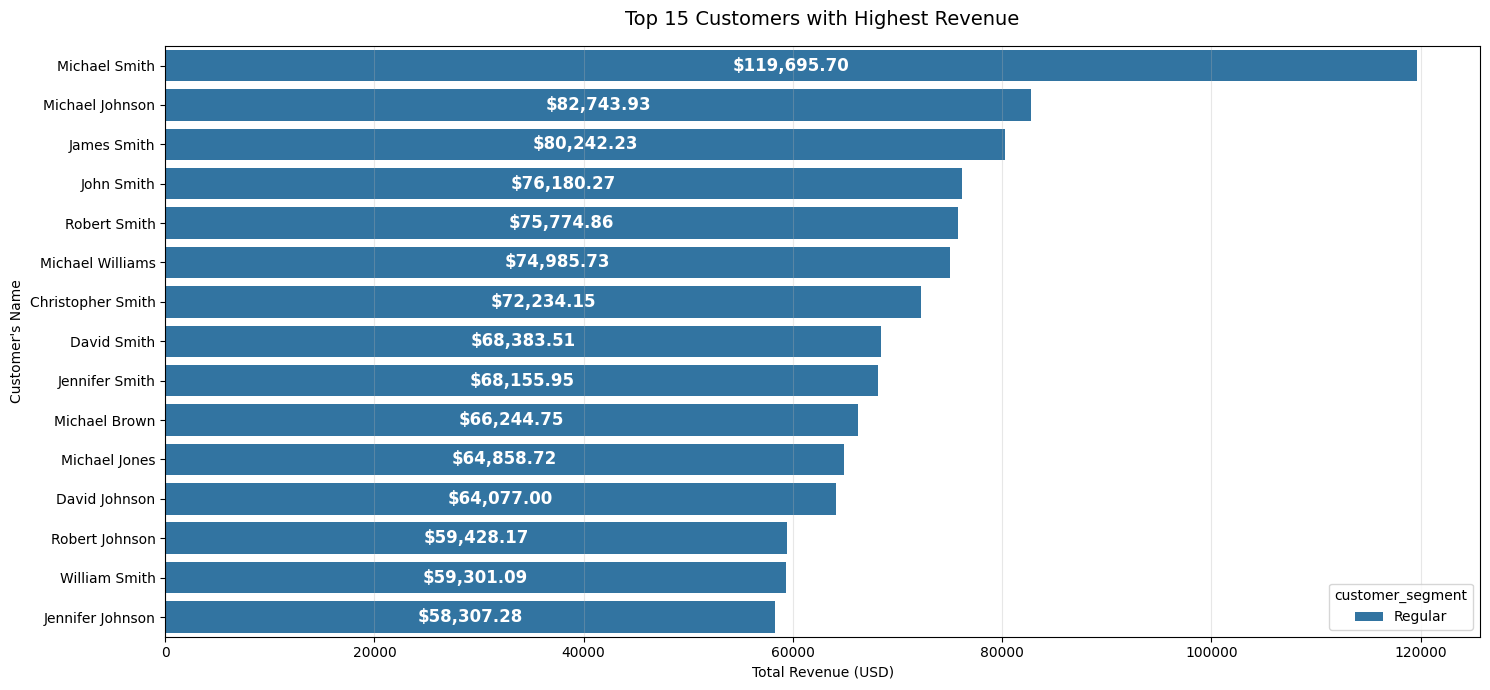

In [36]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment

customers_highest_revenue = sales_df.groupby(['customer_name','customer_segment'])['net_revenue_usd'].sum().reset_index().sort_values('net_revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customers_highest_revenue,
    x='net_revenue_usd',
    y='customer_name',
    hue='customer_segment',
    palette='tab10'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Top 15 Customers with Highest Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Customer's Name")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

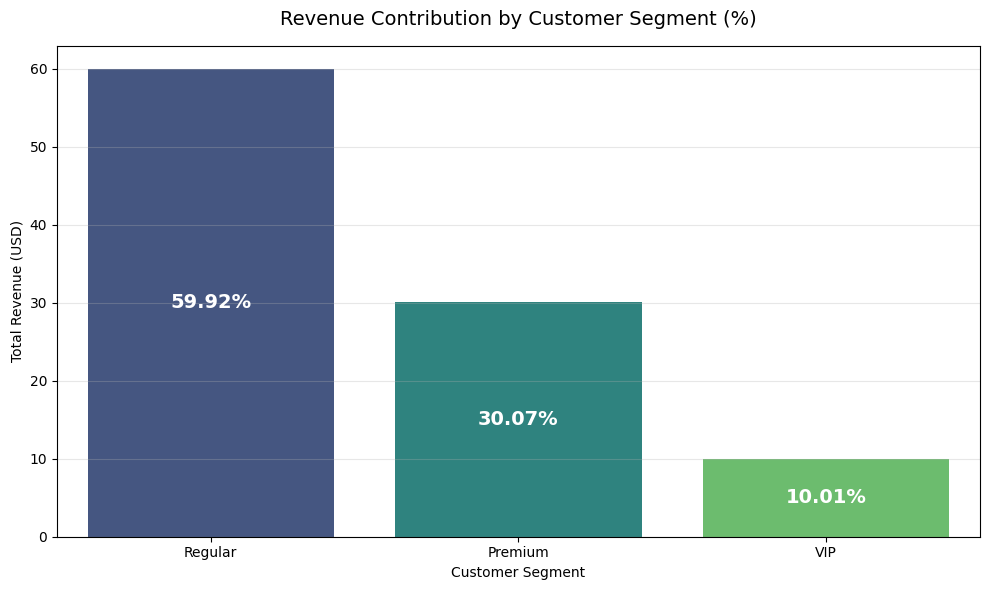

In [37]:
# 1.5.2 Customer Segment Revenue

customer_segment_revenue = sales_df.groupby('customer_segment')['net_revenue_usd'].sum().reset_index().sort_values('net_revenue_usd', ascending=False).head(15)

total_revenue = customer_segment_revenue['net_revenue_usd'].sum()
customer_segment_revenue['revenue_pct'] = (customer_segment_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_pct',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Total Revenue (USD)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

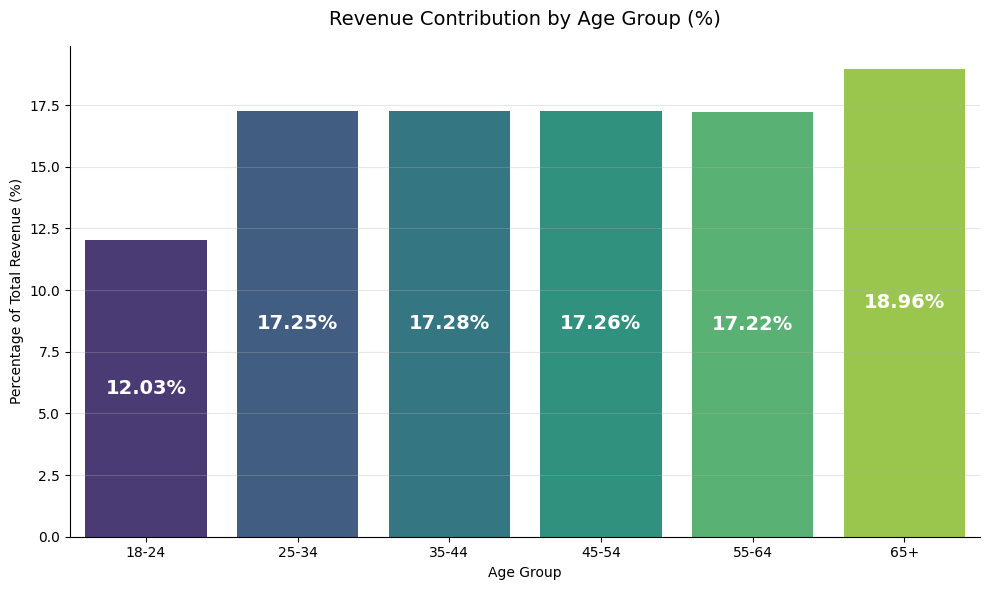

In [38]:
# 1.5.3 Age Group Revenue 

age_group_revenue = (
    sales_df.groupby('age_group')['net_revenue_usd']
    .sum()
    .reindex(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
    .reset_index()
)

total_revenue = age_group_revenue['net_revenue_usd'].sum()
age_group_revenue['revenue_pct'] = (age_group_revenue['net_revenue_usd'] / total_revenue) * 100

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=age_group_revenue,
    x='age_group',
    y='revenue_pct',
    palette='viridis',
    hue='age_group',
    legend=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )

plt.title('Revenue Contribution by Age Group (%)', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel('Percentage of Total Revenue (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)

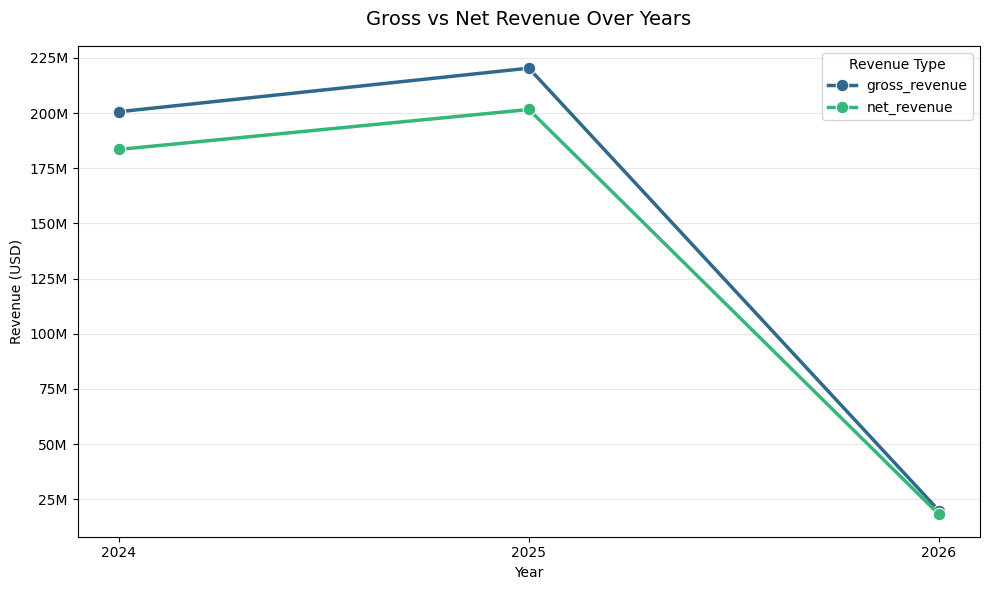

In [39]:
# 1.6.1 Gross Revenue vs Net Revenue (Overall Discount Impact)

yearly = sales_df.groupby('order_year').agg(
    gross_revenue=('gross_revenue_usd', 'sum'),
    net_revenue=('net_revenue_usd', 'sum')
).reset_index()

# Reshape for seaborn
yearly_melted = yearly.melt(
    id_vars='order_year',
    value_vars=['gross_revenue', 'net_revenue'],
    var_name='revenue_type',
    value_name='revenue'
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=yearly_melted,
    x='order_year',
    y='revenue',
    hue='revenue_type',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Gross vs Net Revenue Over Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks(yearly['order_year'])
plt.legend(title='Revenue Type')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

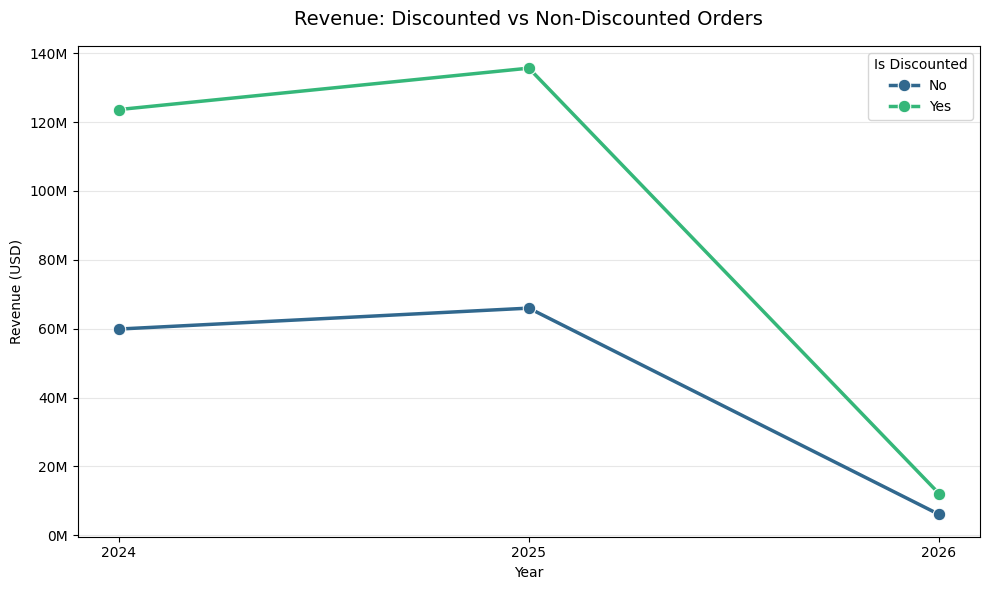

In [40]:
# 1.6.2 Discounted vs Non-Discounted Orders Revenue

discount_rev = (
    sales_df.groupby(['order_year', 'is_discounted'])['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=discount_rev,
    x='order_year',
    y='net_revenue_usd',
    hue='is_discounted',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Revenue: Discounted vs Non-Discounted Orders', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks([2024, 2025, 2026])
plt.legend(title='Is Discounted')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()